In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

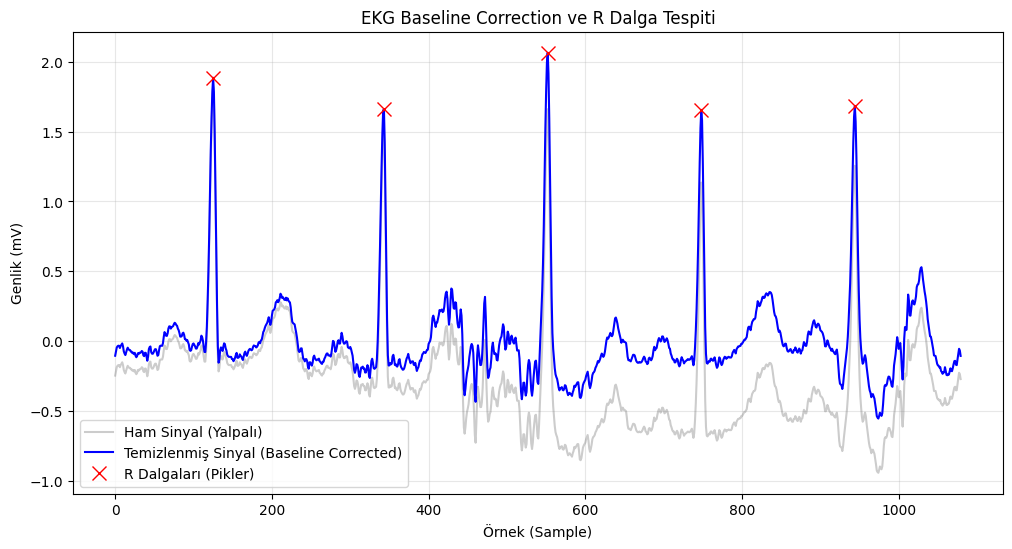

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import scipy.datasets

# 1. Veriyi Hazırlama
ekg = scipy.datasets.electrocardiogram()
ekg = pd.Series(ekg)
fs = 360  # SciPy EKG veri seti 360 Hz örnekleme hızına sahiptir
three_second_ekg = ekg[:1080]

# 2. Baseline Correction Fonksiyonu
def baseline_correction(data, sampling_rate=360):
    # 0.5 Hz altındaki yalpalamaları kesen High-pass Filtre
    nyquist = 0.5 * sampling_rate
    cutoff = 0.5 / nyquist
    b, a = signal.butter(3, cutoff, btype='highpass')
    # Sinyali ileri-geri filtreleyerek faz kaymasını önler (Zero-phase filtering)
    return signal.filtfilt(b, a, data)

# 3. Filtreyi Uygula
cleaned_ekg = baseline_correction(three_second_ekg, sampling_rate=fs)
# Tekrar Series yapalım ki plot() kolay olsun
cleaned_ekg = pd.Series(cleaned_ekg, index=three_second_ekg.index)

# 4. Temizlenmiş Sinyal Üzerinden Pikleri (R-Waves) Bul
# Not: Filtreleme sonrası peak height (yükseklik) biraz değişebilir, 
# 0.8 veya 1.0 eşiğini verine göre kontrol edebilirsin.
r_waves, metadata = signal.find_peaks(cleaned_ekg, height=0.8)

# 5. Görselleştirme
plt.figure(figsize=(12, 6))

# Ham ve Temizlenmiş Sinyali Karşılaştır
plt.plot(three_second_ekg, label="Ham Sinyal (Yalpalı)", alpha=0.4, color='gray')
plt.plot(cleaned_ekg, label="Temizlenmiş Sinyal (Baseline Corrected)", color='blue', linewidth=1.5)

# Bulunan R dalgalarını işaretle
plt.plot(r_waves, cleaned_ekg[r_waves], "x", label="R Dalgaları (Pikler)", color='red', markersize=10)

plt.title("EKG Baseline Correction ve R Dalga Tespiti")
plt.xlabel("Örnek (Sample)")
plt.ylabel("Genlik (mV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()